<a href="https://colab.research.google.com/github/Cralsic123/Ginger/blob/main/Non_reprit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import csv

def txt_to_csv(txt_file, csv_file):
    with open(txt_file, 'r') as infile, open(csv_file, 'w', newline='') as outfile:
        reader = csv.reader(infile, delimiter='\t')
        writer = csv.writer(outfile)
        for row in reader:
            writer.writerow(row)

txt_file = '/content/diabetes.tab.txt'
csv_file = 'diabetes.csv'

txt_to_csv(txt_file, csv_file)

In [3]:
import pandas as pd
df = pd.read_csv("/content/diabetes.csv")
df.head()

,AGE,SEX,BMI,BP,S1,S2,S3,S4,S5,S6,Y
0,59,2,32.1,101.0,157,93.2,38.0,4.0,4.8598,87,151
1,48,1,21.6,87.0,183,103.2,70.0,3.0,3.8918,69,75
2,72,2,30.5,93.0,156,93.6,41.0,4.0,4.6728,85,141
3,24,1,25.3,84.0,198,131.4,40.0,5.0,4.8903,89,206
4,50,1,23.0,101.0,192,125.4,52.0,4.0,4.2905,80,135


In [6]:
df.describe()
# dekh bhai isme sab mean standard deviation diya hai
# yaha se tu value check par gaya kaisa lena hai ya fir nahi

,AGE,SEX,BMI,BP,S1,S2,S3,S4,S5,S6,Y
count,442.000000,442.000000,442.000000,442.000000,442.000000,442.000000,442.000000,442.000000,442.000000,442.000000,442.000000
mean,48.518100,1.468326,26.375792,94.647014,189.140271,115.439140,49.788462,4.070249,4.641411,91.260181,152.133484
std,13.109028,0.499561,4.418122,13.831283,34.608052,30.413081,12.934202,1.290450,0.522391,11.496335,77.093005
min,19.000000,1.000000,18.000000,62.000000,97.000000,41.600000,22.000000,2.000000,3.258100,58.000000,25.000000
25%,38.250000,1.000000,23.200000,84.000000,164.250000,96.050000,40.250000,3.000000,4.276700,83.250000,87.000000
50%,50.000000,1.000000,25.700000,93.000000,186.000000,113.000000,48.000000,4.000000,4.620050,91.000000,140.500000
75%,59.000000,2.000000,29.275000,105.000000,209.750000,134.500000,57.750000,5.000000,4.997200,98.000000,211.500000
max,79.000000,2.000000,42.200000,133.000000,301.000000,242.400000,99.000000,9.090000,6.107000,124.000000,346.000000


In [9]:
df.info()
# isme tu check karega konsa column mein agar koi null count hai ki nahi wagera
# mind it agar null value hoga toh usko us column ke average value se replace kar dena (yeh basic practice hai aur bhi hote hai)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   AGE     442 non-null    int64  
 1   SEX     442 non-null    int64  
 2   BMI     442 non-null    float64
 3   BP      442 non-null    float64
 4   S1      442 non-null    int64  
 5   S2      442 non-null    float64
 6   S3      442 non-null    float64
 7   S4      442 non-null    float64
 8   S5      442 non-null    float64
 9   S6      442 non-null    int64  
 10  Y       442 non-null    int64  
dtypes: float64(6), int64(5)
memory usage: 38.1 KB


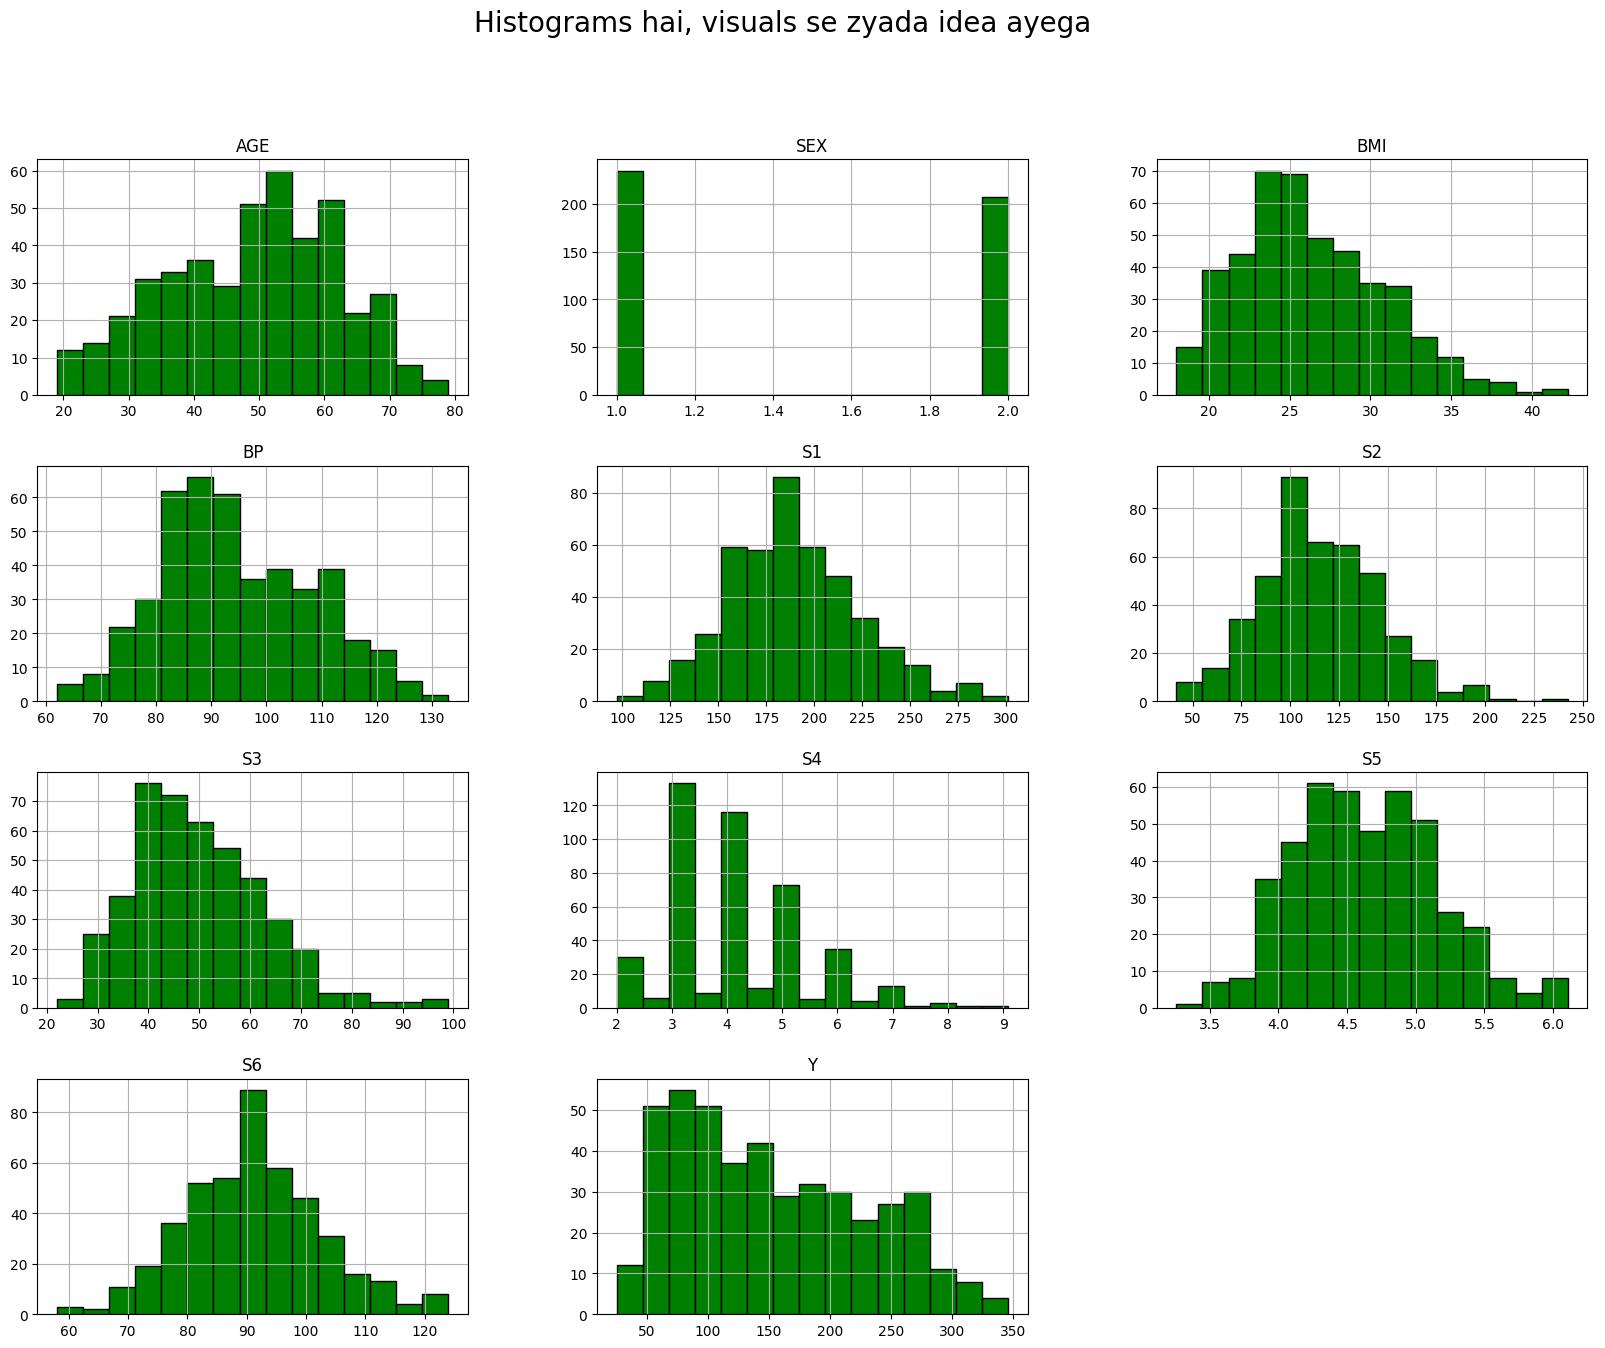

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt
#sns.set(style="whitegrid")
df.hist(bins=15, figsize=(20, 15), color='green', edgecolor='black')
plt.suptitle('Histograms hai, visuals se zyada idea ayega ', fontsize=20)
plt.show()

## Ab dekh humlog har columns ke saath output Y ko correlate kar ke dekh rahe hai ki Y kitna depend karta hai each column ke saath.

<ipython-input-14-6495e527f614>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=correlation_with_Y.index, y=correlation_with_Y.values, palette='viridis')


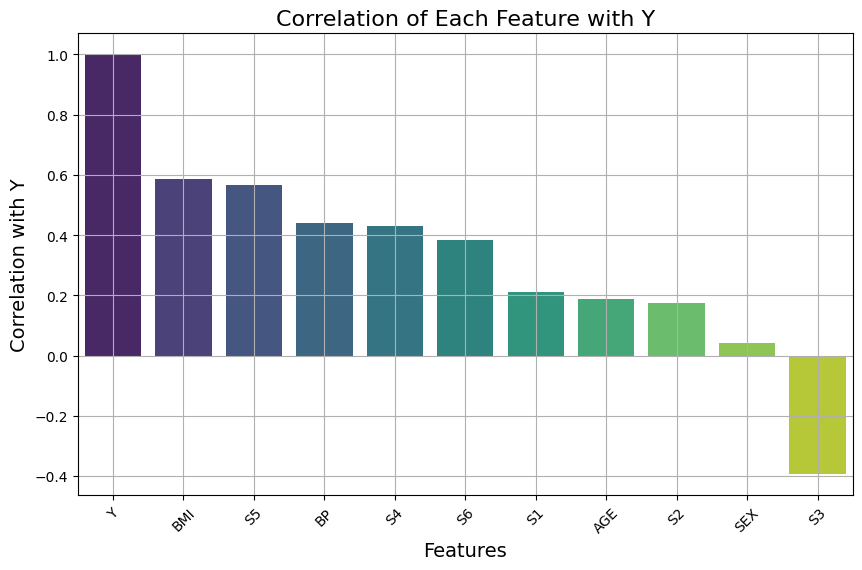

In [14]:
correlation_with_Y = df.corr()['Y'].sort_values(ascending=False)
plt.figure(figsize=(10, 6))
sns.barplot(x=correlation_with_Y.index, y=correlation_with_Y.values, palette='viridis')
plt.title('Correlation of Each Feature with Y', fontsize=16)
plt.xlabel('Features', fontsize=14)
plt.ylabel('Correlation with Y', fontsize=14)
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

## Agar tu dhyan dega toh dekh "SEX" ke saath utna relate nahi karta output Y and S3 ke saath negatively correlate karta hai.

In [17]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

In [15]:
X = df.drop(columns=['Y'])
y = df['Y']

In [18]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [19]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [20]:
y_pred = model.predict(X_test)

In [21]:
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f'Mean Squared Error: {mse}')
print(f'R² Score: {r2}')

Mean Squared Error: 2900.193628493482
R² Score: 0.4526027629719195


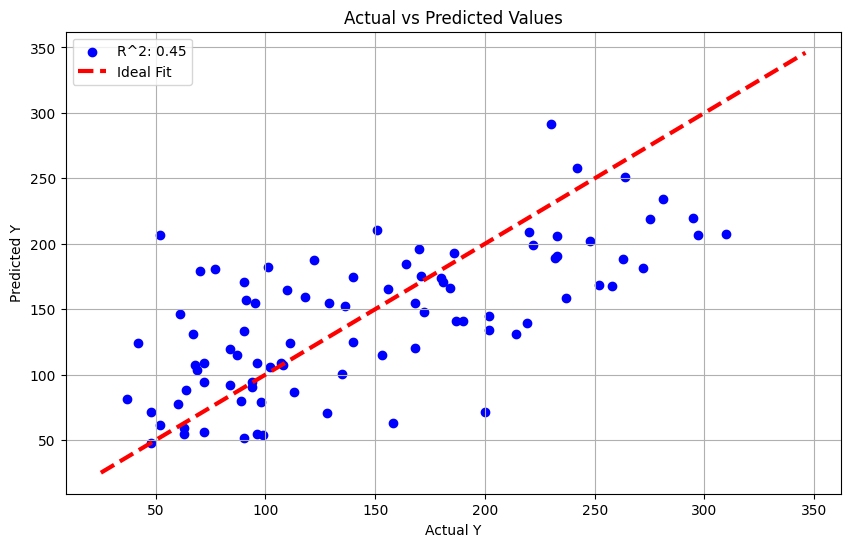

In [22]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, color='blue', label=f'R^2: {r2:.2f}')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=3, label='Ideal Fit')
plt.xlabel('Actual Y')
plt.ylabel('Predicted Y')
plt.title('Actual vs Predicted Values')
plt.legend()
plt.grid(True)
plt.show()

## Ab dekh mein sex wala column ko delete kar ke karunga or S3 wala ko bhi

In [23]:
X = df.drop(columns=['Y', 'S3'])
y = df['Y']

In [24]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [25]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [26]:
y_pred = model.predict(X_test)

In [27]:
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f'Mean Squared Error: {mse}')
print(f'R² Score: {r2}')

Mean Squared Error: 2888.9677762080337
R² Score: 0.4547215871993664


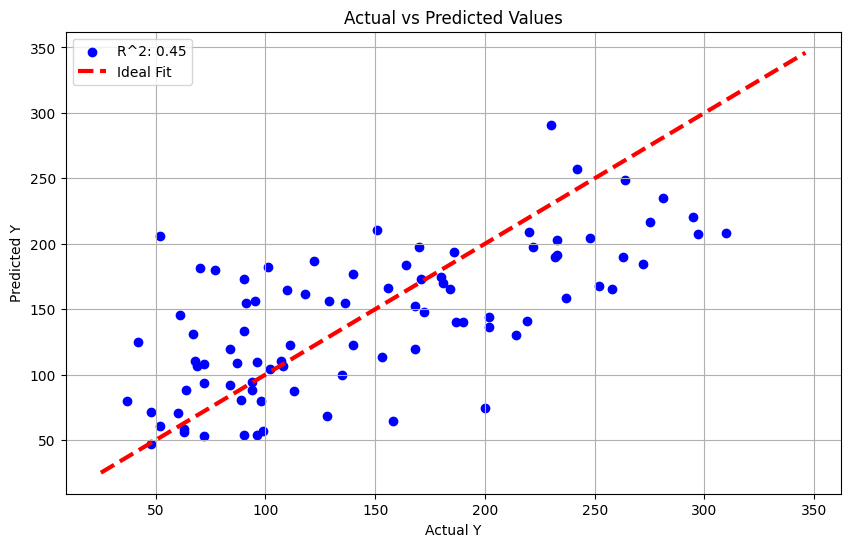

In [28]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, color='blue', label=f'R^2: {r2:.2f}')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=3, label='Ideal Fit')
plt.xlabel('Actual Y')
plt.ylabel('Predicted Y')
plt.title('Actual vs Predicted Values')
plt.legend()
plt.grid(True)
plt.show()

## Dekh R2 score 45% hai toh abhi bohot kam hai accuracy toh humlog ko yeh barana hai. woh tu thora research kar le ki kaise konsa parameter ka weightage increase karne se accuracy baar sakta hai like weightage de columns ko for example us graph mein BMI ke saath zyada correlate hai toh BMI ko zyada weightage de

## ab mein tereko model ko export karke dikhaunga jo tu cloud ya fir api jis platform mein call hoga usme load karna taki api call hoga toh model bhi hoga

In [33]:
import pickle
model_filename = 'model.pkl'
with open(model_filename, 'wb') as file:
    pickle.dump(model, file)

print(f"Model saved ho gaya bhai {model_filename}")

Model saved ho gaya bhai model.pkl


# Ab left mein dekh model agaya .pkl file mein usko download kar le three dots mein click karke thats it.